In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels as sm
import pmdarima as pmd
import seaborn as sns

In [3]:
print(os.getcwd())

/Users/dallin/projects/python-practice/Vending_Analysis


In [4]:
"""
Making sure having everything needed in Vending_Analysis (inventory_turnover and restock_data)
"""

print(os.getcwd())
print(os.listdir())
print(pd.__version__)
print(sm.__version__)
print(pmd.__version__)

/Users/dallin/projects/python-practice/Vending_Analysis
['Inventory_Turnover.csv', 'Restock_data.csv', 'Vending_Analysis1.ipynb']
3.0.5
0.14.6
2.1.1


In [5]:
"""
Assigning inv and restock as variables for both datasets
"""

inv = pd.read_csv('Inventory_Turnover.csv')
restock = pd.read_csv('Restock_data.csv')
"""
Checking the data
"""
inv.head()

,sku,dispense_date,device_id,package_qty,qty_dispensed
0,05d98e5c2603bf927952aa3eb74d1fc3,22-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,20
1,05d98e5c2603bf927952aa3eb74d1fc3,21-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,9
2,05d98e5c2603bf927952aa3eb74d1fc3,20-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,15
3,05d98e5c2603bf927952aa3eb74d1fc3,19-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,13
4,05d98e5c2603bf927952aa3eb74d1fc3,18-02-2024,device_0749c361d8ac7047c2f98fbcb2eadd16,1,24


In [6]:
restock.head()

,device_id,global_order_id,restock_date,currency_code,total
0,device_0749c361d8ac7047c2f98fbcb2eadd16,05f46e618fbb92810f9eed53e2f55a73,2023-12-04 18:09:57.986537,USD,359.58
1,device_65ae7ea424c57d46ac409256fe359349,9af13752287b4011aa8c67572db4fe4a,2023-11-06 15:19:35.630031,USD,344.69
2,device_af645ebf4c96eb6e430529a2a9913686,c444a49754db44199ee59310ab427e53,2023-05-15 12:10:01.056616,USD,338.48
3,device_0749c361d8ac7047c2f98fbcb2eadd16,08dd5a4c6a1d406a3d7f5f2c9f63e752,2024-01-24 15:04:48.844780,USD,43.08
4,device_0749c361d8ac7047c2f98fbcb2eadd16,9bfc4033193d4556360b4729fe25e75c,2023-06-30 14:29:48.834370,USD,177.15


In [7]:
"""
Checking Dtypes, nulls, duplicates
"""

inv.info()

<class 'pandas.DataFrame'>
RangeIndex: 38982 entries, 0 to 38981
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   sku            38982 non-null  str  
 1   dispense_date  38982 non-null  str  
 2   device_id      38982 non-null  str  
 3   package_qty    38982 non-null  int64
 4   qty_dispensed  38982 non-null  int64
dtypes: int64(2), str(3)
memory usage: 4.5 MB


In [8]:
restock.info()

<class 'pandas.DataFrame'>
RangeIndex: 722 entries, 0 to 721
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   device_id        722 non-null    str    
 1   global_order_id  722 non-null    str    
 2   restock_date     722 non-null    str    
 3   currency_code    722 non-null    str    
 4   total            722 non-null    float64
dtypes: float64(1), str(4)
memory usage: 98.8 KB


In [9]:
## Checking nulls and duplicates ##

print(f"""
Inv Table Null Values: 
{inv.isnull().sum()}

Inv Duplicated:
{inv.duplicated().sum()}
""")

print(f"""
Restock Table Null Values: 
{restock.isnull().sum()}

Restock Duplicated:
{restock.duplicated().sum()}
""")
# print(inv.duplicated().sum())
# print(restock.isnull().sum())
# print(restock.duplicated().sum())


Inv Table Null Values: 
sku              0
dispense_date    0
device_id        0
package_qty      0
qty_dispensed    0
dtype: int64

Inv Duplicated:
0


Restock Table Null Values: 
device_id          0
global_order_id    0
restock_date       0
currency_code      0
total              0
dtype: int64

Restock Duplicated:
0



In [10]:
"""
Converting to_datetime, matching both dataframes so they're same date format
"""

inv['dispense_date'] = pd.to_datetime(inv['dispense_date'], format='%d-%m-%Y')
restock['restock_date'] = pd.to_datetime(restock['restock_date'])

In [11]:
## Making sure they're both datetime64[ns] ##
print(inv['dispense_date'].dtype)
print(inv['dispense_date'].min(), inv['dispense_date'].max())

print(restock['restock_date'].dtype)
print(restock['restock_date'].min(), restock['restock_date'].max())

datetime64[us]
2022-02-23 00:00:00 2024-02-23 00:00:00
datetime64[us]
2023-03-24 15:34:41.410836 2024-03-18 12:14:48.176890


In [12]:
inv['qty_dispensed'].describe()

count    38982.000000
mean         8.145503
std          9.055199
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
max        162.000000
Name: qty_dispensed, dtype: float64

In [13]:
"""
No nulls, duplicates found numerically, converted to real datetime64
Converting text to category-type
"""

inv['device_id'] = inv['device_id'].astype('category')
inv['sku'] = inv['sku'].astype('category')
restock['device_id'] = restock['device_id'].astype('category')

In [14]:
## Having mean, median, std, etc... checking numbers ##
restock['total'].describe()

count    722.000000
mean     272.511260
std      101.077273
min        5.090000
25%      207.997500
50%      271.385000
75%      338.707500
max      612.210000
Name: total, dtype: float64

In [15]:
## Is there any currency besides USD to account for? ##
restock['currency_code'].value_counts()

currency_code
USD    722
Name: count, dtype: int64

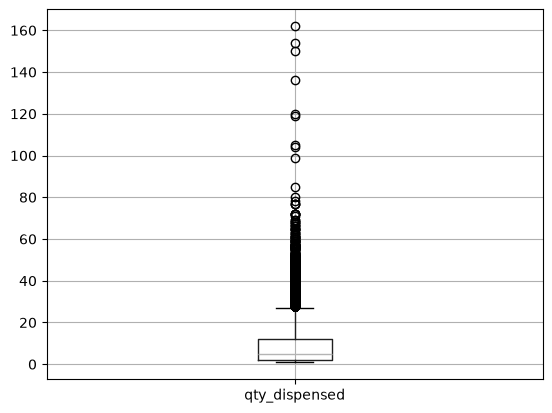

In [16]:
## numbers seem to coincide with the visual ##
inv.boxplot(column='qty_dispensed')
plt.show()

In [17]:
## Checking further any missing days, below just shows holiday, no flags ##
full_range = pd.date_range(inv['dispense_date'].min(), inv['dispense_date'].max(), freq='D')
missing_days = full_range.difference(inv['dispense_date'].unique())
print(missing_days)

DatetimeIndex(['2022-12-24', '2022-12-25', '2023-12-25'], dtype='datetime64[us]', freq=None)


In [18]:
"""
Conduct EDA (Exploratory Data Analysis):

"""

print(f"Inventory (dispense): {inv.shape[0]:,} rows")
print(f"Date range: {inv['dispense_date'].min().date()} to {inv['dispense_date'].max().date()}")
print(f"Unique SKUs: {inv['sku'].nunique()} | Unique devices: {inv['device_id'].nunique()}")
print()
print(f"Restock: {restock.shape[0]:,} rows")
print(f"Date range: {restock['restock_date'].min().date()} to {restock['restock_date'].max().date()}")

Inventory (dispense): 38,982 rows
Date range: 2022-02-23 to 2024-02-23
Unique SKUs: 82 | Unique devices: 5

Restock: 722 rows
Date range: 2023-03-24 to 2024-03-18


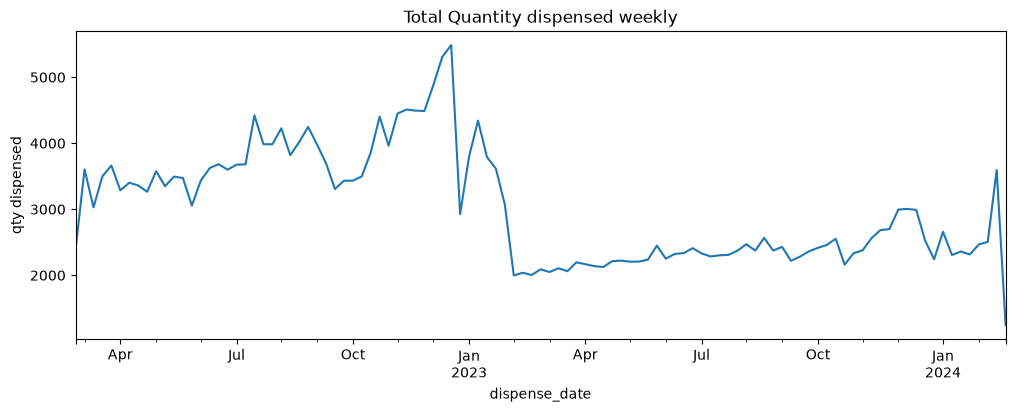

In [19]:
## showing weekly dispensed in ##
weekly_dispensed = inv.set_index('dispense_date')['qty_dispensed'].resample('W').sum()
weekly_dispensed.plot(figsize=(12,4), title='Total Quantity dispensed weekly')
plt.ylabel('qty dispensed')
plt.show()

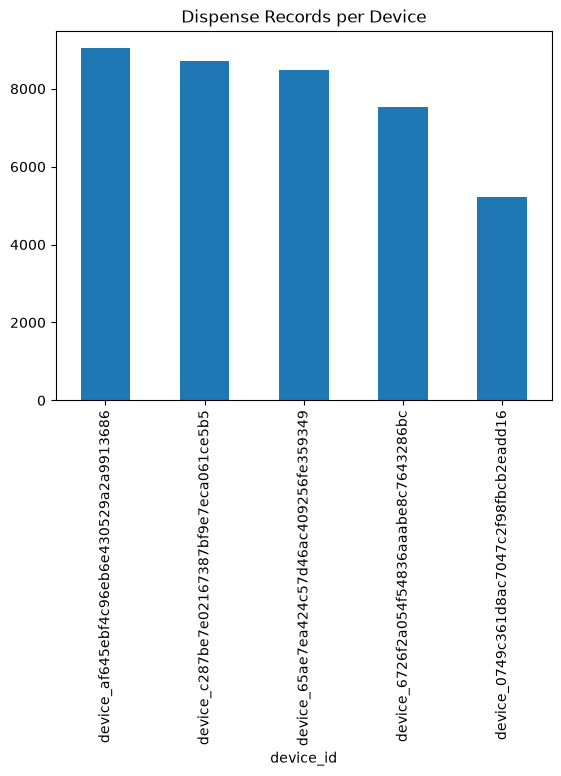

In [20]:
inv['device_id'].value_counts().plot(kind='bar', title='Dispense Records per Device')
plt.show()

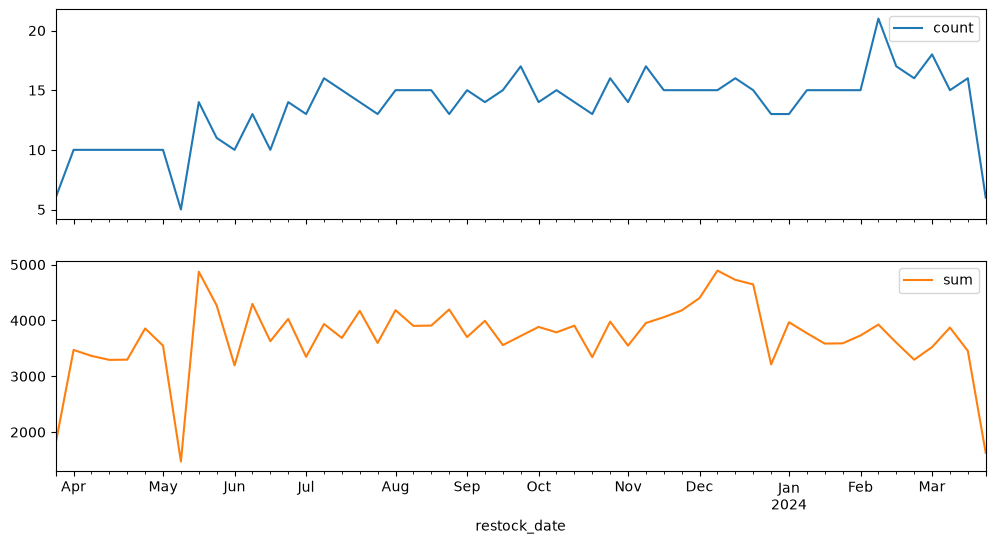

In [21]:
"""
Exploring correlations between quantity dispensed and restock frequency
"""
weekly_restocks = restock.set_index('restock_date')['total'].resample('W').agg(['count','sum'])
weekly_restocks.plot(subplots=True, figsize=(12,6))
plt.show()

In [22]:
"""
Datetime set up to use for Trends/Seasonilty
"""

inv['day_of_week'] = inv['dispense_date'].dt.day_name()
inv['month'] = inv['dispense_date'].dt.month
inv['quarter'] = inv['dispense_date'].dt.quarter
inv['is_weekend'] = inv['dispense_date'].dt.dayofweek >= 5

restock['day_of_week'] = restock['restock_date'].dt.day_name()
restock['month'] = restock['restock_date'].dt.month


In [23]:
daily_total = inv.groupby('dispense_date')['qty_dispensed'].sum().reset_index()
daily_total['lag_1'] = daily_total['qty_dispensed'].shift(1)
daily_total['rolling_7_day'] = daily_total['qty_dispensed'].rolling(7).mean()


In [24]:
daily_total.head(10)

,dispense_date,qty_dispensed,lag_1,rolling_7_day
0,2022-02-23,503,NaN,NaN
1,2022-02-24,472,503.0,NaN
2,2022-02-25,465,472.0,NaN
3,2022-02-26,417,465.0,NaN
4,2022-02-27,541,417.0,NaN
5,2022-02-28,549,541.0,NaN
6,2022-03-01,509,549.0,493.714286
7,2022-03-02,558,509.0,501.571429
8,2022-03-03,554,558.0,513.285714
9,2022-03-04,457,554.0,512.142857


In [25]:
inv['qty_dispensed'].describe()

count    38982.000000
mean         8.145503
std          9.055199
min          1.000000
25%          2.000000
50%          5.000000
75%         12.000000
max        162.000000
Name: qty_dispensed, dtype: float64

In [26]:
inv['qty_dispensed'].value_counts()

qty_dispensed
1      7719
2      5303
3      3672
4      2705
5      2086
       ... 
71        1
136       1
104       1
80        1
162       1
Name: count, Length: 84, dtype: int64

In [27]:
sku_counts = inv['sku'].value_counts()
sku_counts.describe()

count     82.000000
mean     475.390244
std      250.980829
min        2.000000
25%      214.250000
50%      560.500000
75%      692.750000
max      726.000000
Name: count, dtype: float64

In [28]:
inv['day_of_week'].value_counts()

day_of_week
Wednesday    5711
Thursday     5654
Monday       5634
Sunday       5522
Friday       5507
Tuesday      5484
Saturday     5470
Name: count, dtype: int64

In [29]:
inv['month'].value_counts()

month
8     3411
7     3404
10    3328
11    3325
5     3305
3     3278
9     3272
6     3266
12    3221
1     3208
4     3193
2     2771
Name: count, dtype: int64

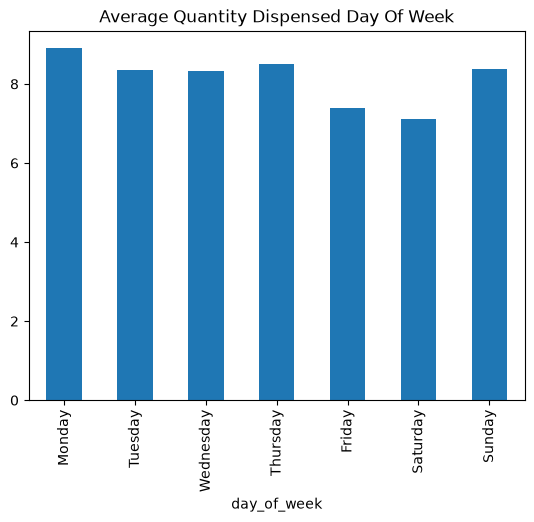

In [30]:
"""
These are showing the AVERAGES of the qty_dispensed, not totals. 
"""

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_of_week = inv.groupby('day_of_week')['qty_dispensed'].mean().reindex(order)
day_of_week.plot(kind='bar', title='Average Quantity Dispensed Day Of Week')
plt.show()

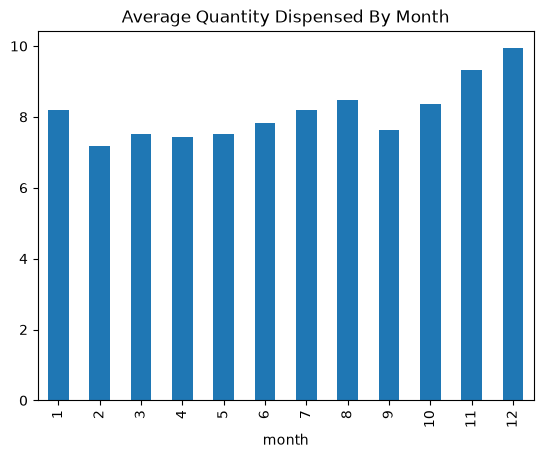

In [31]:
month_avg = inv.groupby('month')['qty_dispensed'].mean()
month_avg.plot(kind='bar', title='Average Quantity Dispensed By Month')
plt.show()


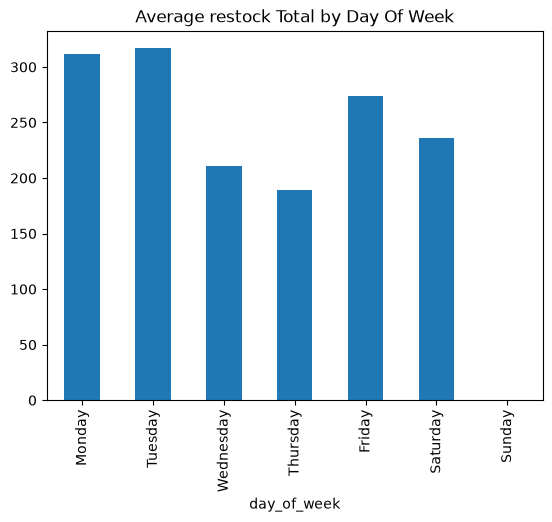

In [32]:
"""
Now restock to look at the average totals
"""

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
restock_dow = restock.groupby('day_of_week')['total'].mean().reindex(order)
restock_dow.plot(kind='bar', title='Average restock Total by Day Of Week')
plt.show()

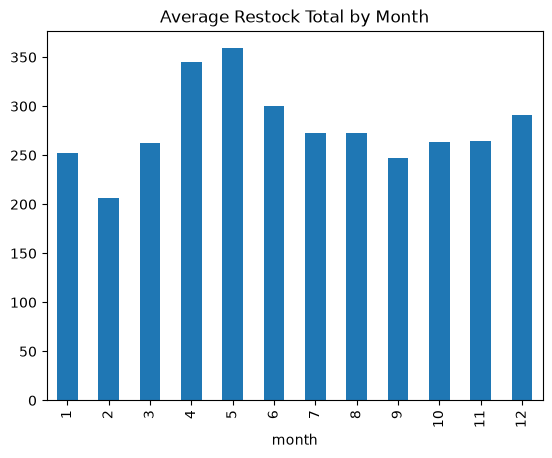

In [33]:
restock_month = restock.groupby('month')['total'].mean()
restock_month.plot(kind='bar', title='Average Restock Total by Month')
plt.show()

In [34]:
"""
Product Analysis, Demand Variability by SKU, Seasonilty, etc... 
Since SKU is the product, we'll see which product has highest turnover.
"""
### The total top 10 most dispensed products ###
sku_total = inv.groupby('sku')['qty_dispensed'].sum().sort_values(ascending=False)
sku_total.head(10)

sku
b1cfc8c80d03027941b0bce8d2ff3deb    21845
be61be55295db1941eaf232ee6288fa7    17273
93d664dddeea2dd49decf97035051e92    16395
9a154810b166b91ae0c3d0cd84fb7e05    16083
da3562c59621dd135d3f0255d3fb66aa    14683
ff9575eadeeb732ad8095286dc2bff82    13167
690b7d2f4218991b6496be8eb456a943    12829
b701576d3b2e8ea055ac68016e01668e    12307
05d98e5c2603bf927952aa3eb74d1fc3    12052
78baaaf1b752a5358cb6835cf1a7ef8d    10842
Name: qty_dispensed, dtype: int64

In [35]:
"""
Highest product with most unpredictable demand/inconsistency
"""
sku_stats = inv.groupby('sku')['qty_dispensed'].agg(['mean','std','count'])
sku_stats['cv'] = sku_stats['std'] / sku_stats['mean']
sku_stats.sort_values('cv', ascending=False).head(10)

,mean,std,count,cv
sku,,,,
1fc36e6327e578011358e52fcedfda9a,3.169312,2.810174,567,0.886683
9d60025d39c34f6d75a0110e3957b79b,1.617391,1.373832,115,0.849412
d8f674f1baeb28ba583c9c467e67365d,2.911392,2.456380,553,0.843713
01bdf04bb36dfcd94a9ef6fce31afc59,1.766537,1.292998,257,0.731940
912562560d2e2e4558eed7feaaf1cba1,3.626230,2.635111,610,0.726681
59aeef56921214e309d716079777bdbc,2.345455,1.694195,495,0.722331
9d65874b97267d3f2ec157913f6db867,3.620094,2.572246,637,0.710547
a7f48cf1fe39ef9712cb253ca5fe8bc5,1.222222,0.861475,54,0.704843
66133559e0f832da8500b2127d18f9dc,2.224779,1.558808,565,0.700657


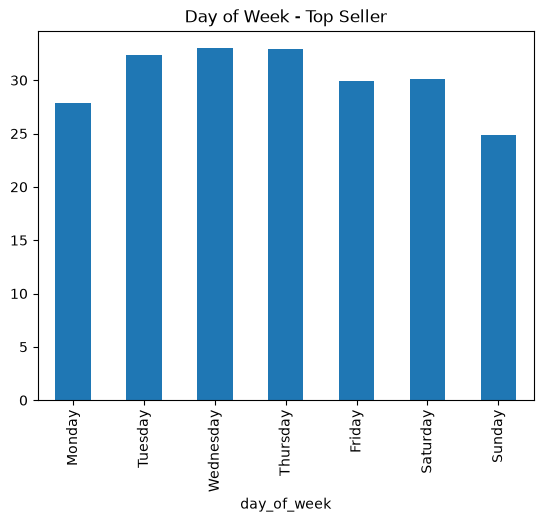

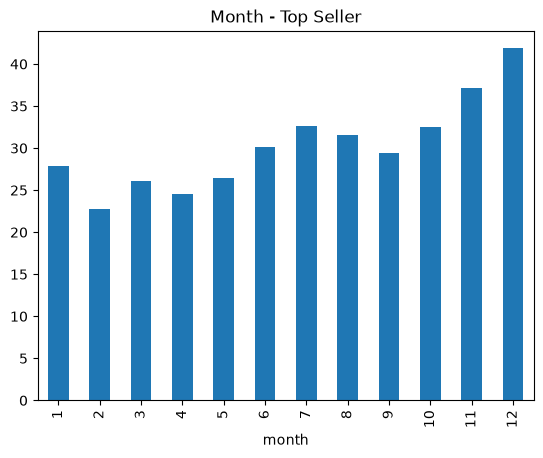

In [36]:
top_sku = sku_total.index[0]
sku_data = inv[inv['sku'] == top_sku]

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sku_data.groupby('day_of_week')['qty_dispensed'].mean().reindex(order).plot(kind='bar', title='Day of Week - Top Seller')
plt.show()

sku_data.groupby('month')['qty_dispensed'].mean().plot(kind='bar', title='Month - Top Seller')
plt.show()

In [37]:
"""
correlation matrix, none go towards 1 or -1, they seem balanced
"""
overlap_start = restock['restock_date'].min()
weekly_dispensed = inv[inv['dispense_date']>=overlap_start].set_index('dispense_date')['qty_dispensed'].resample('W').sum()
weekly_restock = restock.set_index('restock_date')['total'].resample('W').agg(['count','sum'])

merged = pd.DataFrame({'dispensed': weekly_dispensed}).join(weekly_restock, how='inner')
merged = merged.rename(columns={'count':'restock_count','sum':'restock_total'})
merged.corr()


,dispensed,restock_count,restock_total
dispensed,1.000000,0.482961,0.582918
restock_count,0.482961,1.000000,0.618194
restock_total,0.582918,0.618194,1.000000


In [38]:
"""
All 5 devices stay active
"""
device_stats = inv.groupby('device_id')['qty_dispensed'].agg(['sum', 'mean', 'count'])
device_stats

,sum,mean,count
device_id,,,
device_0749c361d8ac7047c2f98fbcb2eadd16,58788,11.270706,5216
device_65ae7ea424c57d46ac409256fe359349,67741,7.985500,8483
device_6726f2a054f54836aaabe8c7643286bc,70397,9.332759,7543
device_af645ebf4c96eb6e430529a2a9913686,59568,6.592297,9036
device_c287be7e02167387bf9e7eca061ce5b5,61034,7.012178,8704


In [39]:
device_date_uniq = inv.groupby('device_id')['dispense_date'].nunique()
device_date_uniq

device_id
device_0749c361d8ac7047c2f98fbcb2eadd16    728
device_65ae7ea424c57d46ac409256fe359349    724
device_6726f2a054f54836aaabe8c7643286bc    728
device_af645ebf4c96eb6e430529a2a9913686    728
device_c287be7e02167387bf9e7eca061ce5b5    722
Name: dispense_date, dtype: int64

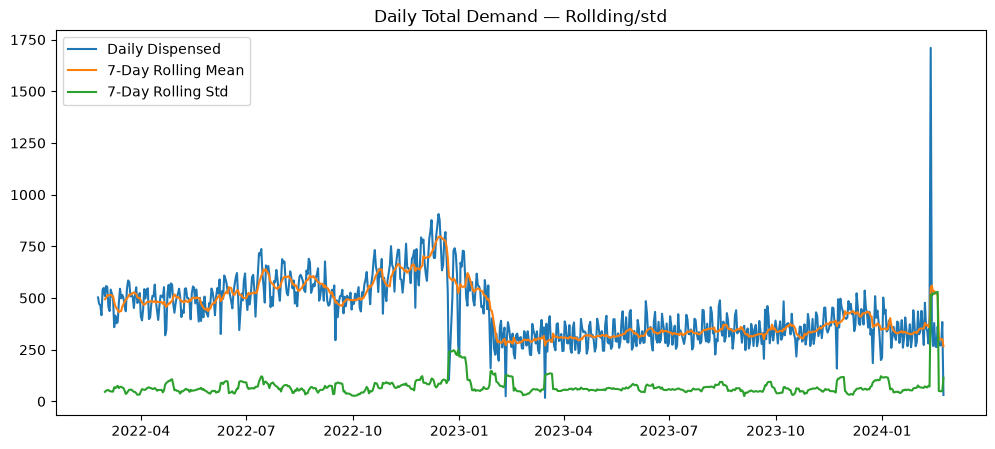

In [40]:
"""
Predictive Modeling: checking whether daily demand drifts or grows in variance
full history
"""
daily_total['rolling_7_std'] = daily_total['qty_dispensed'].rolling(7).std()

plt.figure(figsize=(12,5))
plt.plot(daily_total['dispense_date'], daily_total['qty_dispensed'], label='Daily Dispensed')
plt.plot(daily_total['dispense_date'], daily_total['rolling_7_day'], label='7-Day Rolling Mean')
plt.plot(daily_total['dispense_date'], daily_total['rolling_7_std'], label='7-Day Rolling Std')
plt.legend()
plt.title('Daily Total Demand — Rollding/std')
plt.show()

In [41]:
"""
All 5 devices span the exact same date range
"""
inv.groupby('device_id')['dispense_date'].agg(['min', 'max'])

,min,max
device_id,,
device_0749c361d8ac7047c2f98fbcb2eadd16,2022-02-23,2024-02-23
device_65ae7ea424c57d46ac409256fe359349,2022-02-23,2024-02-23
device_6726f2a054f54836aaabe8c7643286bc,2022-02-23,2024-02-23
device_af645ebf4c96eb6e430529a2a9913686,2022-02-23,2024-02-23
device_c287be7e02167387bf9e7eca061ce5b5,2022-02-23,2024-02-23


In [42]:
# What's actually happening on the spike day? #
spike_row = daily_total.sort_values('qty_dispensed', ascending=False).iloc[0]
print(spike_row)
spike_date = spike_row['dispense_date']
inv[inv['dispense_date'] == spike_date].groupby('device_id')['qty_dispensed'].sum()

dispense_date    2024-02-12 00:00:00
qty_dispensed                   1710
lag_1                          415.0
rolling_7_day             550.142857
rolling_7_std             516.476662
Name: 716, dtype: object


device_id
device_0749c361d8ac7047c2f98fbcb2eadd16    397
device_65ae7ea424c57d46ac409256fe359349    374
device_6726f2a054f54836aaabe8c7643286bc    230
device_af645ebf4c96eb6e430529a2a9913686    274
device_c287be7e02167387bf9e7eca061ce5b5    435
Name: qty_dispensed, dtype: int64

In [43]:
daily_total['rolling_30_day'] = daily_total['qty_dispensed'].rolling(30).mean()
daily_total['change_30'] = daily_total['rolling_30_day'].diff()
daily_total.sort_values('change_30').head(5)[['dispense_date', 'rolling_30_day', 'change_30']]

,dispense_date,rolling_30_day,change_30
303,2022-12-23,698.800000,-20.933333
350,2023-02-10,403.500000,-18.400000
337,2023-01-28,517.633333,-18.333333
310,2023-01-01,672.433333,-17.900000
344,2023-02-04,455.966667,-17.633333


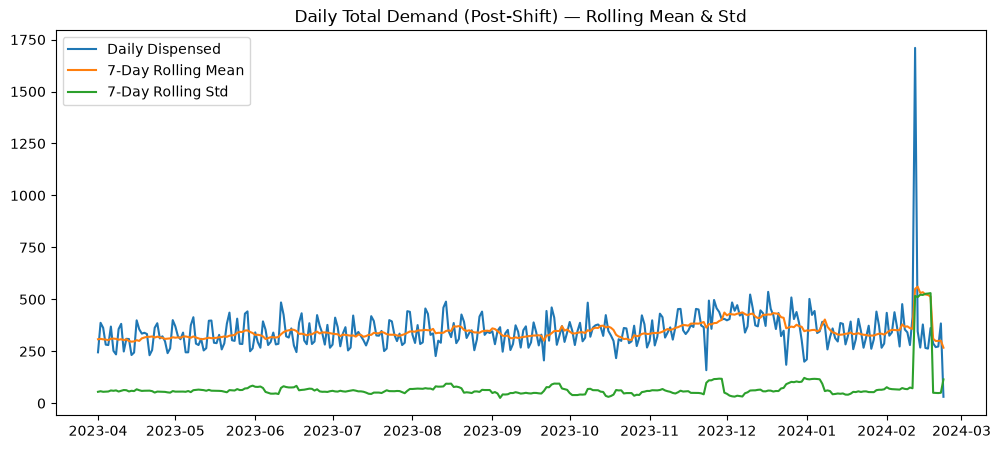

In [44]:
"""
Building from 2023-04 from this point creating model data for the ADF
"""

model_data = daily_total[daily_total['dispense_date'] >= '2023-04-01'].reset_index(drop=True)

plt.figure(figsize=(12,5))
plt.plot(model_data['dispense_date'], model_data['qty_dispensed'], label='Daily Dispensed')
plt.plot(model_data['dispense_date'], model_data['rolling_7_day'], label='7-Day Rolling Mean')
plt.plot(model_data['dispense_date'], model_data['rolling_7_std'], label='7-Day Rolling Std')
plt.legend()
plt.title('Daily Total Demand (Post-Shift) — Rolling Mean & Std')
plt.show()

In [45]:
from statsmodels.tsa.stattools import adfuller
"""
Raw daily demand numbers, p = 0.125 -- not low enough to call it statistically
stationary
"""
adf_result = adfuller(model_data['qty_dispensed'], autolag='AIC')
labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
for label, value in zip(labels, adf_result[:4]):
    print(f'{label}: {value}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -2.6581172340881176
p-value: 0.08157041996850439
# Lags Used: 14
# Observations: 313
Critical Values:
   1%: -3.4514162625887037
   5%: -2.8708187088091406
   10%: -2.5717136883095675


In [46]:
"""
model_data p-value = 5.6 × 10⁻¹⁴, stationary
"""

model_data['diff_1'] = model_data['qty_dispensed'].diff()

adf_diff = adfuller(model_data['diff_1'].dropna(), autolag='AIC')
for label, value in zip(labels, adf_diff[:4]):
    print(f'{label}: {value}')
print('Critical Values:')
for key, value in adf_diff[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -8.131104520901154
p-value: 1.0896788286682766e-12
# Lags Used: 13
# Observations: 313
Critical Values:
   1%: -3.4514162625887037
   5%: -2.8708187088091406
   10%: -2.5717136883095675


In [47]:
train = model_data.iloc[:-30]
test = model_data.iloc[-30:]

print(f"Train: {train['dispense_date'].min().date()} to {train['dispense_date'].max().date()} ({len(train)} days)")
print(f"Test: {test['dispense_date'].min().date()} to {test['dispense_date'].max().date()} ({len(test)} days)")

Train: 2023-04-01 to 2024-01-24 (298 days)
Test: 2024-01-25 to 2024-02-23 (30 days)


In [48]:
import pmdarima as pmd

model = pmd.auto_arima(
    train['qty_dispensed'],
    d=1,
    seasonal=True,
    m=7,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=3194.310, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=3482.173, Time=0.00 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=3315.952, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=3480.176, Time=0.00 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=0.54 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=3299.297, Time=0.08 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=3186.300, Time=0.67 sec
 ARIMA(1,1,2)(2,0,2)[7] intercept   : AIC=3184.005, Time=0.59 sec
 ARIMA(1,1,2)(1,0,2)[7] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(

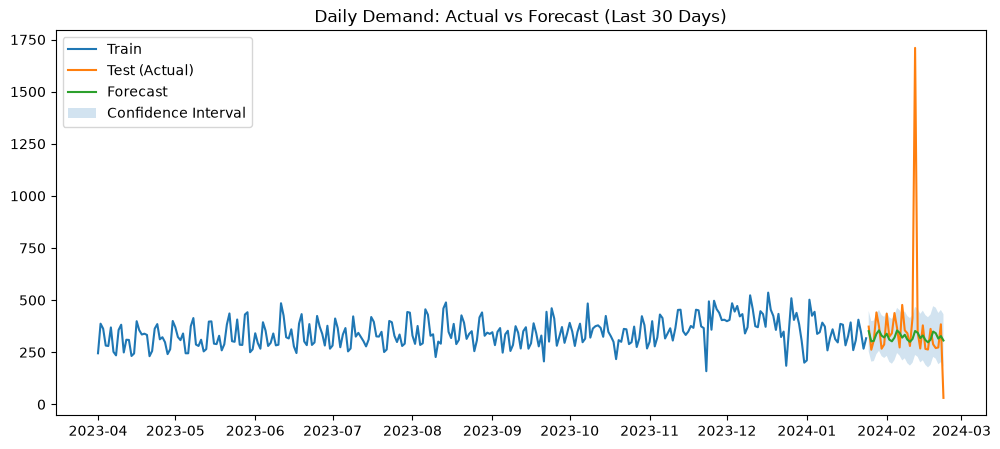

In [49]:
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)

test = test.copy()
test['forecast'] = forecast.values if hasattr(forecast, 'values') else forecast
test['conf_low'] = conf_int[:, 0]
test['conf_high'] = conf_int[:, 1]

plt.figure(figsize=(12,5))
plt.plot(train['dispense_date'], train['qty_dispensed'], label='Train')
plt.plot(test['dispense_date'], test['qty_dispensed'], label='Test (Actual)')
plt.plot(test['dispense_date'], test['forecast'], label='Forecast')
plt.fill_between(test['dispense_date'], test['conf_low'], test['conf_high'], alpha=0.2, label='Confidence Interval')
plt.legend()
plt.title('Daily Demand: Actual vs Forecast (Last 30 Days)')
plt.show()

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['qty_dispensed'], test['forecast']))
mae = mean_absolute_error(test['qty_dispensed'], test['forecast'])
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 260.04
MAE: 101.88


In [51]:
model.update(test['qty_dispensed'])

,order,"(0, ...)"
,seasonal_order,"(2, ...)"
,suppress_warnings,True
,scoring_args,{}
,with_intercept,False
,start_params,None
,method,'lbfgs'
,maxiter,50
,out_of_sample_size,0
,scoring,'mse'
,trend,None


In [52]:
future_periods = 14
future_forecast, future_conf = model.predict(n_periods=future_periods, return_conf_int=True)

future_dates = pd.date_range(
    start=model_data['dispense_date'].max() + pd.Timedelta(days=1),
    periods=future_periods,
    freq='D'
)

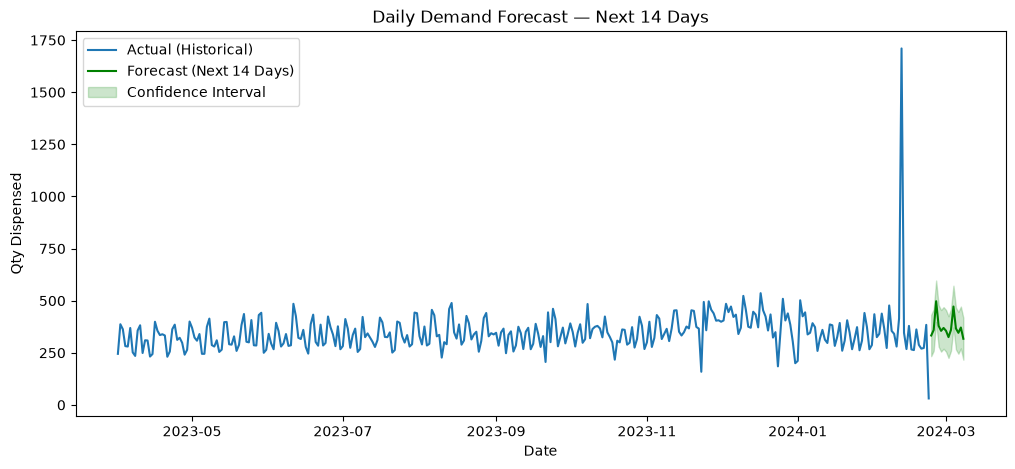

In [53]:
plt.figure(figsize=(12,5))
plt.plot(model_data['dispense_date'], model_data['qty_dispensed'], label='Actual (Historical)')
plt.plot(future_dates, future_forecast, label='Forecast (Next 14 Days)', color='green')
plt.fill_between(future_dates, future_conf[:,0], future_conf[:,1], color='green', alpha=0.2, label='Confidence Interval')
plt.legend()
plt.title('Daily Demand Forecast — Next 14 Days')
plt.xlabel('Date')
plt.ylabel('Qty Dispensed')
plt.show()